In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import glob

In [2]:
# import boto3

# s3 = boto3.client("s3")

# bucket = "euliaa-l2" 
# prefix = "Andoya/L2A/20MIN/"   # root of bucket

# paginator = s3.get_paginator("list_objects_v2")

# file_list = []
# for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
#     if "Contents" in page:
#         for obj in page["Contents"]:
#             if obj["Key"].endswith(".nc"):
#                 print(obj["Key"])
#                 file_list.append(f"s3://{bucket}/{obj['Key']}")


In [20]:
import boto3
import datetime

s3 = boto3.client("s3")

def list_files_in_date_range(bucket, main_prefix, start_date, end_date):
    """
    start_date and end_date are datetime.date objects.
    """
    current = start_date
    results = []

    while current <= end_date:
        # Build S3 prefix: YYYY/MM/DD/
        prefix = main_prefix+current.strftime("/%Y/%m/%d/")
        
        response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)

        if "Contents" in response:
            for obj in response["Contents"]:
                if obj["Key"].endswith(".nc"):
                    results.append(f's3://{bucket}/{obj["Key"]}')
        
        current += datetime.timedelta(days=1)

    return results


# --- Example usage ---
bucket = "euliaa-l2"
main_prefix = "Andoya/L2A/20MIN"
start = datetime.datetime(2025, 11, 3).date()
end   = datetime.datetime(2025, 11, 4).date()

files = list_files_in_date_range(bucket, main_prefix,start, end)
for f in files:
    print(f)


s3://euliaa-l2/Andoya/L2A/20MIN/2025/11/03/L2A20MIN_2025-11-03_00-00-00.nc
s3://euliaa-l2/Andoya/L2A/20MIN/2025/11/04/L2A20MIN_2025-11-04_08-30-00.nc


In [21]:
ds = xr.open_mfdataset(files,concat_dim='time',combine='nested',engine='h5netcdf')

In [14]:
# ds = xr.open_dataset('s3://euliaa-daily/Kuehlungsborn/L2A20MIN_2025-11-21.nc', engine='h5netcdf')
ds2 = xr.open_dataset('s3://euliaa-l2/Andoya/L2A/20MIN/2025/11/01/L2A20MIN_2025-11-01_00-00-00.nc', engine='h5netcdf')

In [22]:
ds = ds.drop_duplicates(dim="time")


In [23]:
ds['w_mie'] = ds.w_mie.where(ds.w_mie_flag == 0, np.nan)
ds2['w_mie'] = ds2.w_mie.where(ds2.w_mie_flag == 0, np.nan)

(0.0, 30000.0)

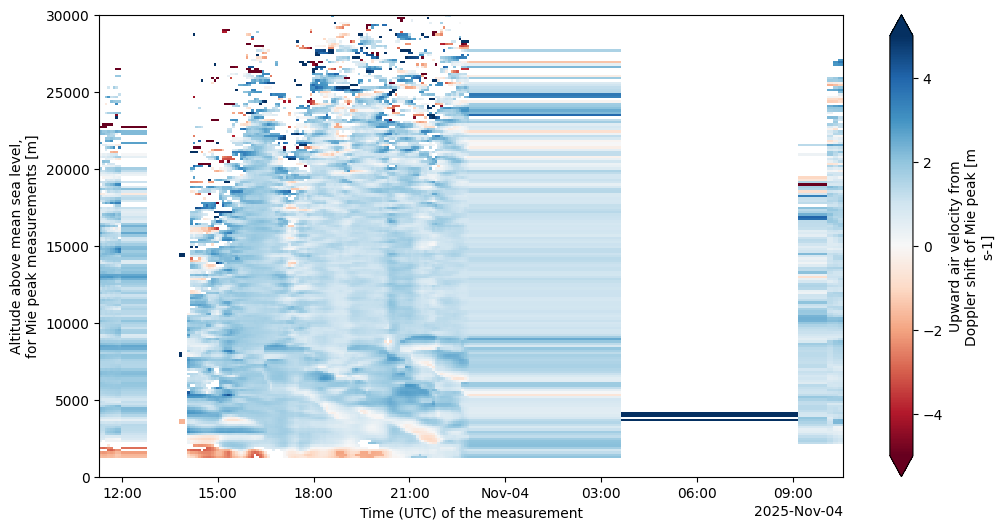

In [25]:
ds.w_mie.plot(x='time', vmin=-5, vmax=5, cmap='RdBu', figsize=(12,6))
plt.ylim(0,30000)
# plt.xlim(ds2.time.min(), ds2.time.max())
# plt.xlim(ds.time.min(), ds.time.min()+np.timedelta64(1,'D'))

In [27]:
w = ds.w_mie
alt = ds.altitude_mie.to_numpy().reshape((1,-1)).repeat(w.sizes['time'], axis=0)
t = ds.time.to_numpy().reshape((-1,1)).repeat(w.sizes['altitude_mie'], axis=1)

In [39]:
mean_w = w.mean().values.item()

(-10.0, 10.0)

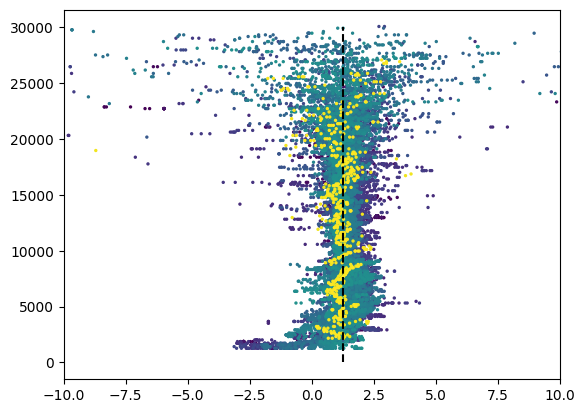

In [40]:
plt.scatter(w,alt,s=2, c=t)
plt.vlines(mean_w,0,30000, colors='k', linestyles='dashed', label='Mean')
plt.xlim(-10,10)

In [41]:
print("Mean w_mie:", mean_w)

Mean w_mie: 1.2690913677215576
